### Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append('../src')
from data_loader import load_raw_data
from cleaning import clean_appointment_data

### Loading Raw Data

In [15]:
df_raw = load_raw_data()
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

Raw data shape: (110527, 14)
Columns: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


### Data Quality Assessment

In [16]:
# === Missing Values ===
print("1. Missing Values per Column:")
missing = df_raw.isnull().sum()
print(missing[missing > 0])

# === Duplicates ===
dup_count = df_raw.duplicated().sum()
print(f"\n2. Duplicate Rows: {dup_count}")

# === Data Types ===
print("\n3. Data Types:")
print(df_raw.dtypes)

# === Target Distribution ===
print("\n4. Target Variable Distribution (No-Show):")
print(df_raw['No-show'].value_counts(normalize=True))

1. Missing Values per Column:
Series([], dtype: int64)

2. Duplicate Rows: 0

3. Data Types:
PatientId         float64
AppointmentID       int64
Gender                str
ScheduledDay          str
AppointmentDay        str
Age                 int64
Neighbourhood         str
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show               str
dtype: object

4. Target Variable Distribution (No-Show):
No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64


### Visualizations

/var/folders/sz/6mrnyfg93lv8bn_xjq3qb3t40000gn/T/ipykernel_31110/358839750.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='No-show', palette='Set2')


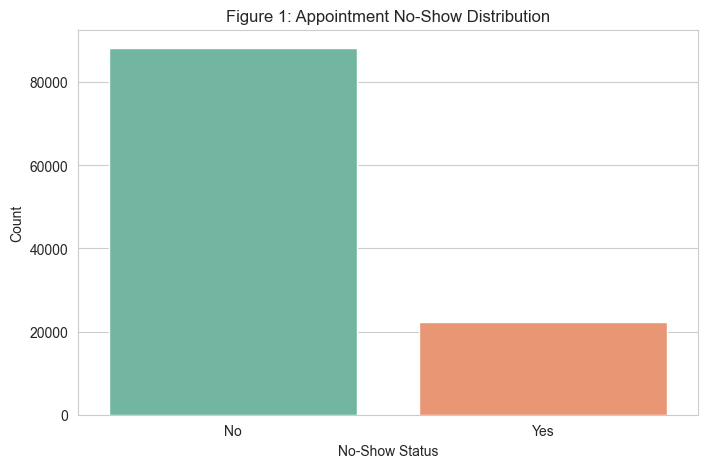

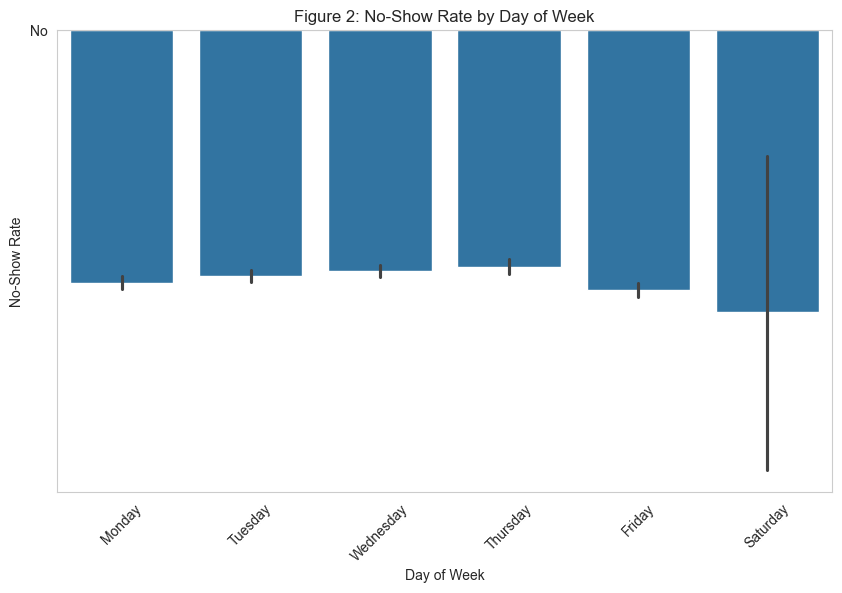

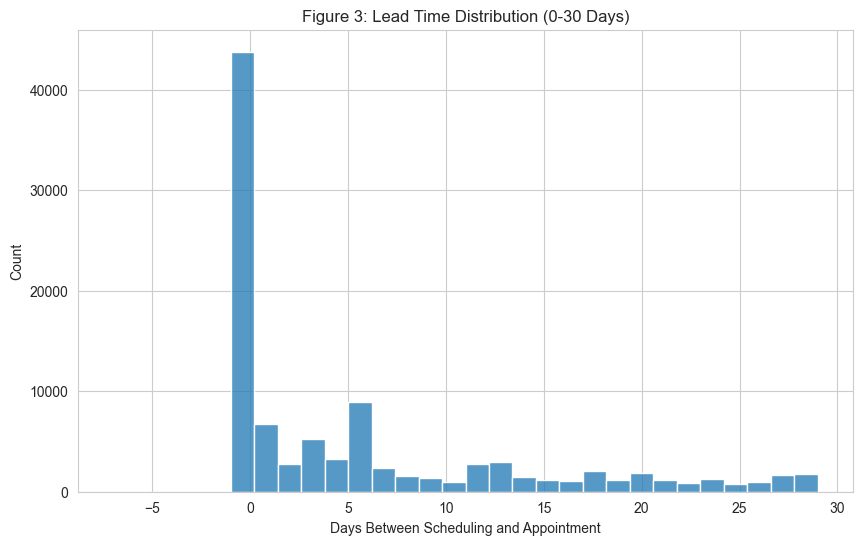

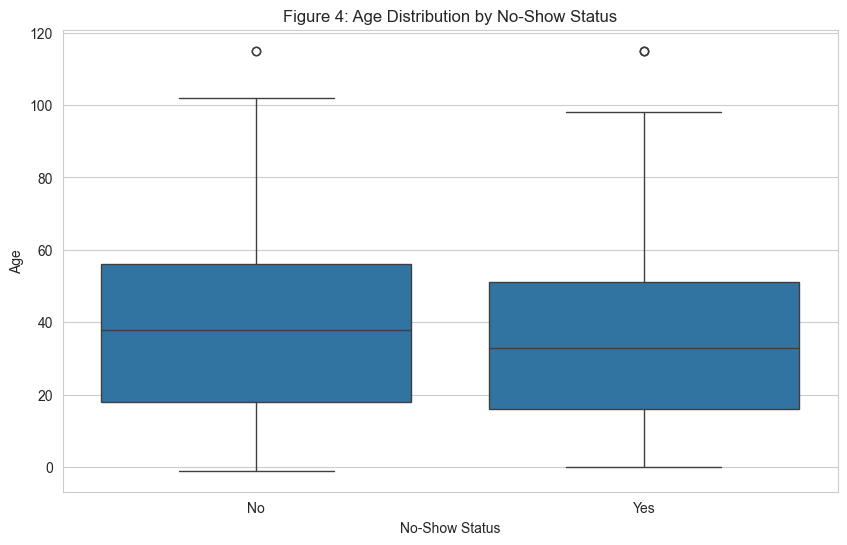

/var/folders/sz/6mrnyfg93lv8bn_xjq3qb3t40000gn/T/ipykernel_31110/358839750.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sms_effect, x='SMS_received', y='No-show', palette='Set1')


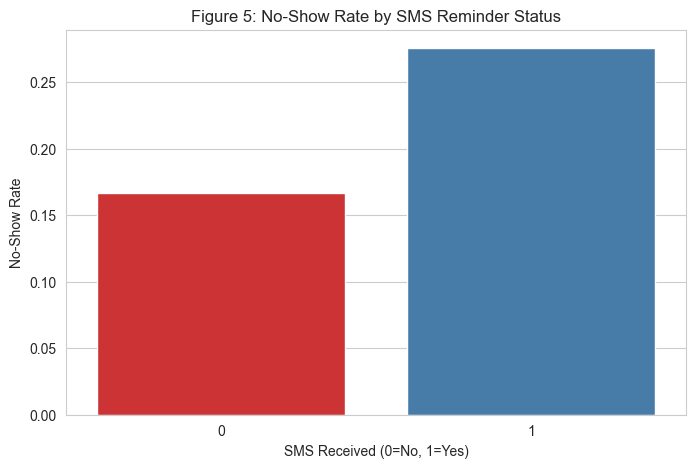

In [17]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# == Target Class Distribution ===
plt.figure(figsize=(8, 5))
sns.countplot(data=df_raw, x='No-show', palette='Set2')
plt.title('Figure 1: Appointment No-Show Distribution')
plt.xlabel('No-Show Status')
plt.ylabel('Count')
plt.savefig('../report/figures/fig1_target_distribution.png', dpi=300)
plt.show()

# === No Show Rate by Day of Week ===
df_raw['AppointmentDay'] = pd.to_datetime(df_raw['AppointmentDay'])
df_raw['day_of_week'] = df_raw['AppointmentDay'].dt.day_name()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_raw, x='day_of_week', y='No-show', 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
plt.title('Figure 2: No-Show Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('No-Show Rate')
plt.xticks(rotation=45)
plt.savefig('../report/figures/fig2_no_show_by_day.png', dpi=300)
plt.show()

# === Lead Time Distribution ===
df_raw['ScheduledDay'] = pd.to_datetime(df_raw['ScheduledDay'])
df_raw['lead_time_days'] = (df_raw['AppointmentDay'] - df_raw['ScheduledDay']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(data=df_raw[df_raw['lead_time_days'] < 30], x='lead_time_days', bins=30)
plt.title('Figure 3: Lead Time Distribution (0-30 Days)')
plt.xlabel('Days Between Scheduling and Appointment')
plt.ylabel('Count')
plt.savefig('../report/figures/fig3_lead_time_dist.png', dpi=300)
plt.show()

# == Age Distribution by No-Show Status ===
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='No-show', y='Age')
plt.title('Figure 4: Age Distribution by No-Show Status')
plt.xlabel('No-Show Status')
plt.ylabel('Age')
plt.savefig('../report/figures/fig4_age_by_no_show.png', dpi=300)
plt.show()

# === SMS Reminder Effectiveness ===
# Convert 'No-show' from string to numeric (Yes=1, No=0)
df_raw['No-show'] = df_raw['No-show'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
sms_effect = df_raw.groupby('SMS_received')['No-show'].mean().reset_index()
sns.barplot(data=sms_effect, x='SMS_received', y='No-show', palette='Set1')
plt.title('Figure 5: No-Show Rate by SMS Reminder Status')
plt.xlabel('SMS Received (0=No, 1=Yes)')
plt.ylabel('No-Show Rate')
plt.savefig('../report/figures/fig5_sms_effect.png', dpi=300)
plt.show()